### [Introduce to Agentic RAG(Retrieval Augmented Generation)](https://huggingface.co/learn/agents-course/en/unit3/agentic-rag/agentic-rag)

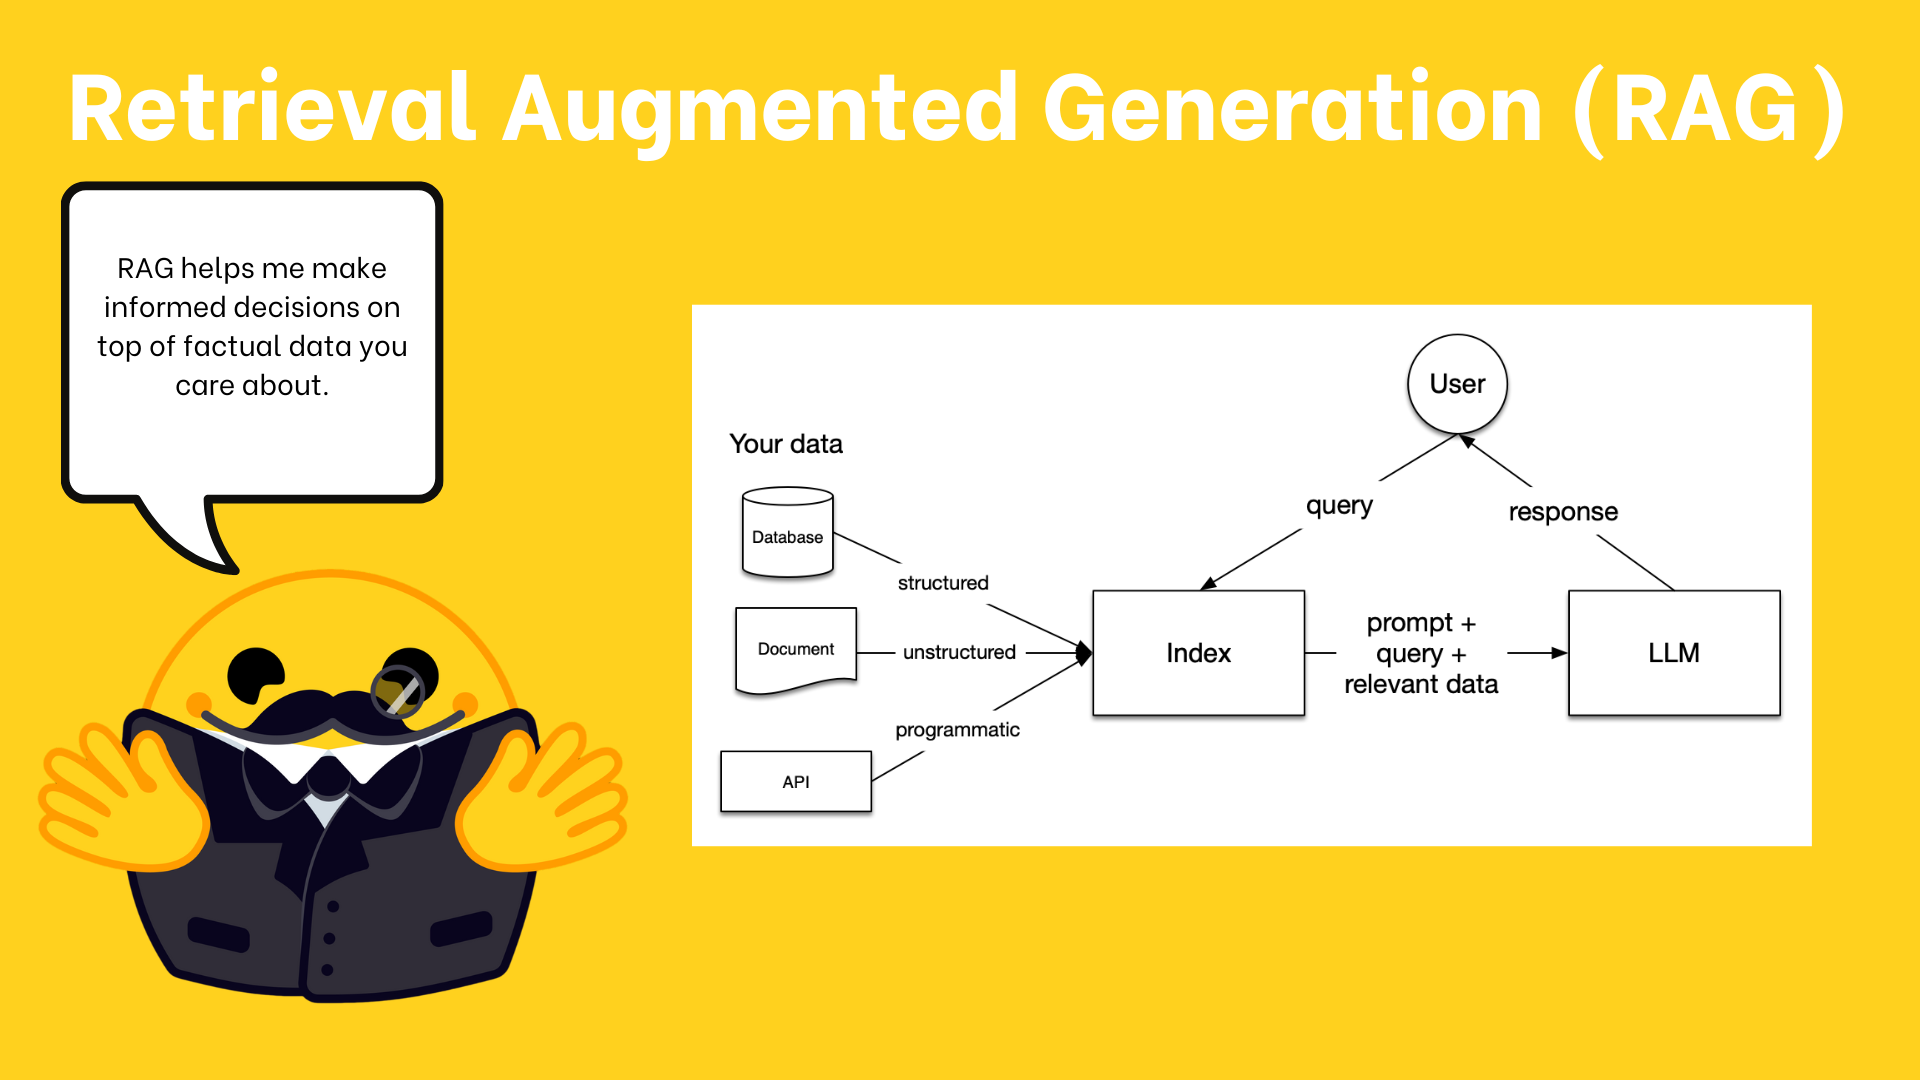

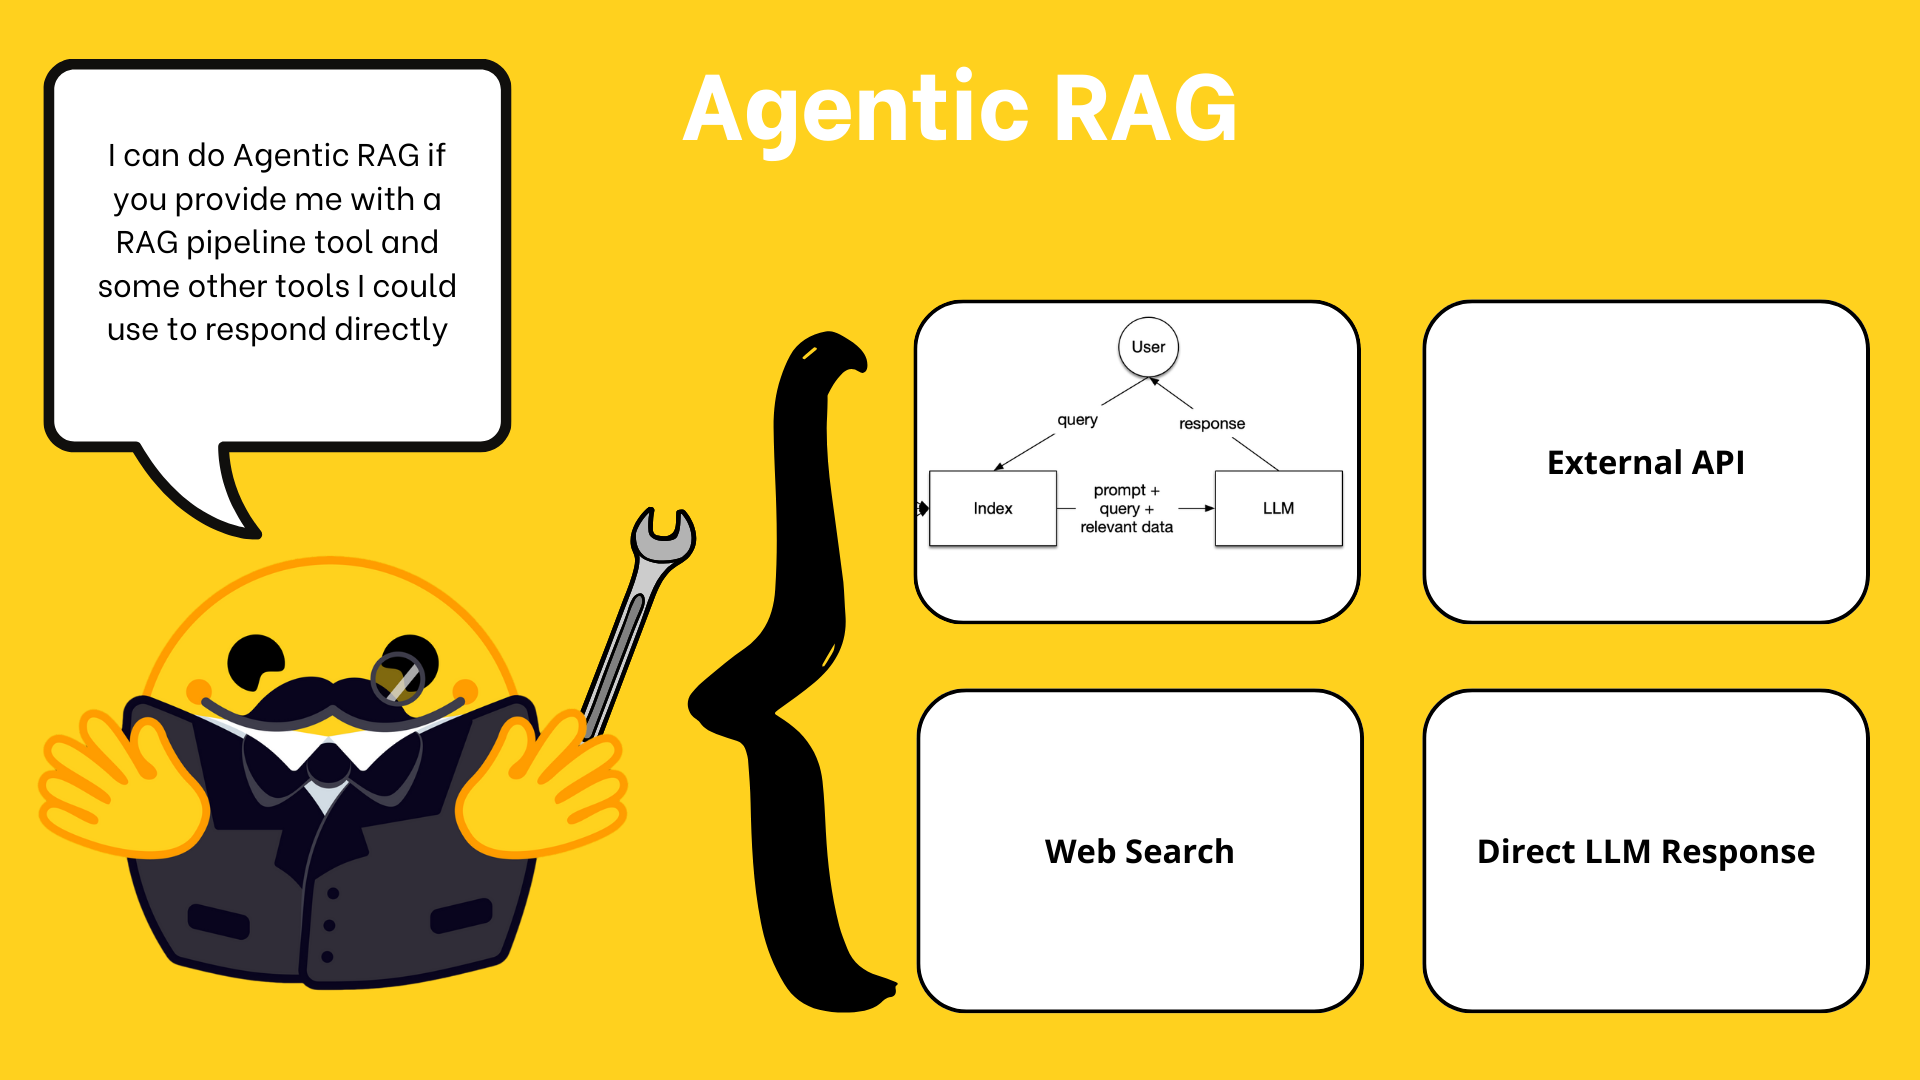

### [Creating a RAG Tool for Guest Stories](https://huggingface.co/learn/agents-course/en/unit3/agentic-rag/invitees?agents-frameworks=langgraph)

STEP 01: Load and Prepare the Dataset

In the code below, we:

- Load the dataset
- Convert each guest entry into a Document object with formatted content
- Store the Document objects in a list  
  
This means we’ve got all of our data nicely available so we can get started with configuring our retrieval.

1. smolagents & langchain

In [1]:
import datasets
from langchain_core.documents import Document

# Load the dataset
guest_dataset = datasets.load_dataset("agents-course/unit3-invitees", split="train")

# Convert dataset entries into Document objects
docs = [
    Document(
        page_content="\n".join([
            f"Name: {guest['name']}",
            f"Relation: {guest['relation']}",
            f"Description: {guest['description']}",
            f"Email: {guest['email']}"
        ]),
        metadata={"name": guest["name"]}
    )
    for guest in guest_dataset
]


README.md:   0%|          | 0.00/371 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.32k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3 [00:00<?, ? examples/s]

2. llama-index

In [ ]:
import datasets
from llama_index.core.schema import Document

# Load the dataset
guest_dataset = datasets.load_dataset("agents-course/unit3-invitees", split="train")

# Convert dataset entries into Document objects
docs = [
    Document(
        text="\n".join([
            f"Name: {guest_dataset['name'][i]}",
            f"Relation: {guest_dataset['relation'][i]}",
            f"Description: {guest_dataset['description'][i]}",
            f"Email: {guest_dataset['email'][i]}"
        ]),
        metadata={"name": guest_dataset['name'][i]}
    )
    for i in range(len(guest_dataset))
]

STEP 02: Create the Retriever Tool

Let’s understand this tool step-by-step.

- The name and description help the agent understand when and how to use this tool
- The type decorators define what parameters the tool expects (in this case, a search query)
- We’re using a BM25Retriever, which is a powerful text retrieval algorithm that doesn’t require embeddings
- The method processes the query and returns the most relevant guest information

1. smolagents

In [2]:
from smolagents import Tool
from langchain_community.retrievers import BM25Retriever

class GuestInfoRetrieverTool(Tool):
    name = "guest_info_retriever"
    description = "Retrieves detailed information about gala guests based on their name or relation."
    inputs = {
        "query": {
            "type": "string",
            "description": "The name or relation of the guest you want information about."
        }
    }
    output_type = "string"

    def __init__(self, docs):
        self.is_initialized = False
        self.retriever = BM25Retriever.from_documents(docs)

    def forward(self, query: str):
        results = self.retriever.invoke(query)
        if results:
            return "\n\n".join([doc.page_content for doc in results[:3]])
        else:
            return "No matching guest information found."

# Initialize the tool
guest_info_tool = GuestInfoRetrieverTool(docs)

/tmp/ipykernel_10213/3722892848.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


2. llama-index

In [ ]:
from llama_index.core.tools import FunctionTool
from llama_index.retrievers.bm25 import BM25Retriever

bm25_retriever = BM25Retriever.from_defaults(nodes=docs)

def get_guest_info_retriever(query: str) -> str:
    """Retrieves detailed information about gala guests based on their name or relation."""
    results = bm25_retriever.retrieve(query)
    if results:
        return "\n\n".join([doc.text for doc in results[:3]])
    else:
        return "No matching guest information found."

# Initialize the tool
guest_info_tool = FunctionTool.from_defaults(get_guest_info_retriever)

3. langgraph

In [ ]:
from llama_index.core.tools import FunctionTool
from llama_index.retrievers.bm25 import BM25Retriever

bm25_retriever = BM25Retriever.from_defaults(nodes=docs)

def get_guest_info_retriever(query: str) -> str:
    """Retrieves detailed information about gala guests based on their name or relation."""
    results = bm25_retriever.retrieve(query)
    if results:
        return "\n\n".join([doc.text for doc in results[:3]])
    else:
        return "No matching guest information found."

# Initialize the tool
guest_info_tool = FunctionTool.from_defaults(get_guest_info_retriever)

STEP 03: Integrate the Tool with Alfred

1. smolagents

In [3]:
from smolagents import CodeAgent, InferenceClientModel

# Initialize the Hugging Face model
model = InferenceClientModel()

# Create Alfred, our gala agent, with the guest info tool
alfred = CodeAgent(tools=[guest_info_tool], model=model)

# Example query Alfred might receive during the gala
response = alfred.run("Tell me about our guest named 'Lady Ada Lovelace'.")

print("🎩 Alfred's Response:")
print(response)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Tell me about our guest named 'Lady Ada Lovelace'.                                                              │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  guest_info = guest_info_retriever(query="Lady Ada Lovelace")                                                     
  print(guest_info)                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Name: Ada Lovelace
Relation: best friend
Description: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for 
her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work
on Charles Babbage's Analytical Engine.
Email: ada.lovelace@example.com

Name: Marie Curie
Relation: no relation
Description: Marie Curie was a groundbreaking physicist and chemist, famous for her research on radioactivity.
Email: marie.curie@example.com

Name: Dr. Nikola Tesla
Relation: old friend from university days
Description: Dr. Nikola Tesla is an old friend from your university days. He's recently patented a new wireless 
energy transmission system and would be delighted to discuss it with you. Just remember he's passionate about 
pigeons, so that might make for good small talk.
Email: nikola.tesla@gmail.com

Out: None

[Step 1: Duration 3.62 seconds| Input tokens: 2,087 | Output tokens: 424]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  entries = guest_info.strip().split('\n\n')                                                                       
  ada_description = None                                                                                           
  for entry in entries:                                                                                            
      lines = entry.split('\n')                                                                                    
      if lines[0] == "Name: Ada Lovelace":                                                                         
          for line in lines:                                                                                       
              if line.startswith("Description: "):                                                                 
                  ada_description = line[13:]                                                                      
                  break                                                                                            
          break                                                                                                    
  final_answer(ada_description)                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for
her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work
on Charles Babbage's Analytical Engine.

[Step 2: Duration 20.72 seconds| Input tokens: 4,518 | Output tokens: 4,668]

🎩 Alfred's Response:
Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work on Charles Babbage's Analytical Engine.


In [4]:
# Example query Alfred might receive during the gala
response = alfred.run("Alfred, who is that gentleman talking to the ambassador?")

print("🎩 Alfred's Response:")
print(response)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Alfred, who is that gentleman talking to the ambassador?                                                        │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen3-Next-80B-A3B-Thinking ───────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  info = guest_info_retriever(query="gentleman talking to ambassador")                                             
  print(info)                                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
Name: Ada Lovelace
Relation: best friend
Description: Lady Ada Lovelace is my best friend. She is an esteemed mathematician and friend. She is renowned for 
her pioneering work in mathematics and computing, often celebrated as the first computer programmer due to her work
on Charles Babbage's Analytical Engine.
Email: ada.lovelace@example.com

Name: Dr. Nikola Tesla
Relation: old friend from university days
Description: Dr. Nikola Tesla is an old friend from your university days. He's recently patented a new wireless 
energy transmission system and would be delighted to discuss it with you. Just remember he's passionate about 
pigeons, so that might make for good small talk.
Email: nikola.tesla@gmail.com

Name: Marie Curie
Relation: no relation
Description: Marie Curie was a groundbreaking physicist and chemist, famous for her research on radioactivity.
Email: marie.curie@example.com

Out: None

[Step 1: Duration 8.72 seconds| Input tokens: 2,086 | Output tokens: 1,483]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Dr. Nikola Tesla")                                                                                 
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Dr. Nikola Tesla

[Step 2: Duration 13.50 seconds| Input tokens: 4,522 | Output tokens: 3,673]

🎩 Alfred's Response:
Dr. Nikola Tesla


2. llama-index

In [ ]:
from llama_index.core.agent.workflow import AgentWorkflow
from llama_index.llms.huggingface_api import HuggingFaceInferenceAPI

# Initialize the Hugging Face model
llm = HuggingFaceInferenceAPI(model_name="Qwen/Qwen2.5-Coder-32B-Instruct")

# Create Alfred, our gala agent, with the guest info tool
alfred = AgentWorkflow.from_tools_or_functions(
    [guest_info_tool],
    llm=llm,
)

# Example query Alfred might receive during the gala
response = await alfred.run("Tell me about our guest named 'Lady Ada Lovelace'.")

print("🎩 Alfred's Response:")
print(response)

3. langgraph

In [ ]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# Generate the chat interface, including the tools
llm = HuggingFaceEndpoint(
    repo_id="Qwen/Qwen2.5-Coder-32B-Instruct",
    huggingfacehub_api_token=HUGGINGFACEHUB_API_TOKEN,
)

chat = ChatHuggingFace(llm=llm, verbose=True)
tools = [guest_info_tool]
chat_with_tools = chat.bind_tools(tools)

# Generate the AgentState and Agent graph
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

def assistant(state: AgentState):
    return {
        "messages": [chat_with_tools.invoke(state["messages"])],
    }

## The graph
builder = StateGraph(AgentState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message requires a tool, route to tools
    # Otherwise, provide a direct response
    tools_condition,
)
builder.add_edge("tools", "assistant")
alfred = builder.compile()

messages = [HumanMessage(content="Tell me about our guest named 'Lady Ada Lovelace'.")]
response = alfred.invoke({"messages": messages})

print("🎩 Alfred's Response:")
print(response['messages'][-1].content)